In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cantidad de ventanas: 59867
Característica analizada: RMS

ANÁLISIS DE LA CARACTERÍSTICA: RMS
Periodo detectado mediante ACF: 1747 ventanas
Periodo dominante mediante periodograma: 1575.45 ventanas
Frecuencia dominante normalizada: 0.000635 ciclos/ventana


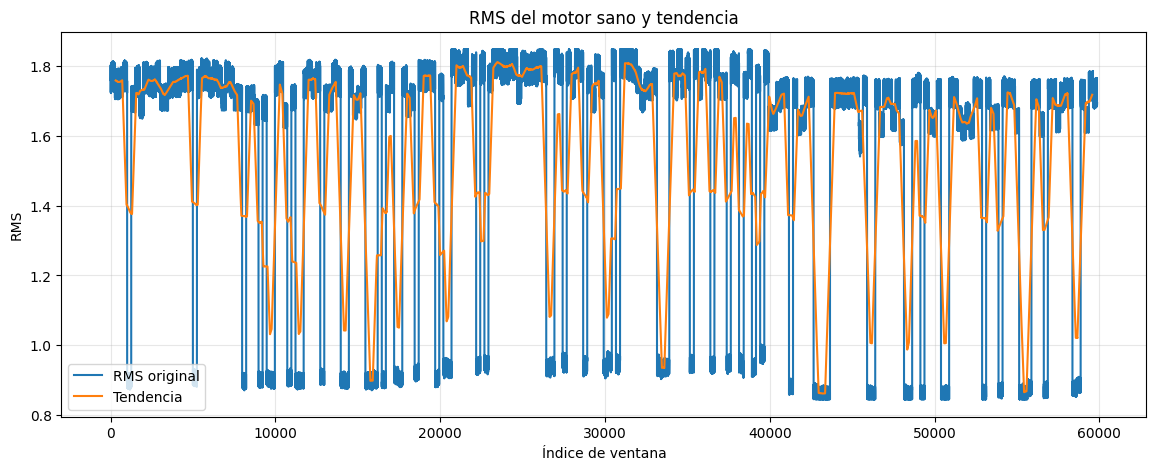

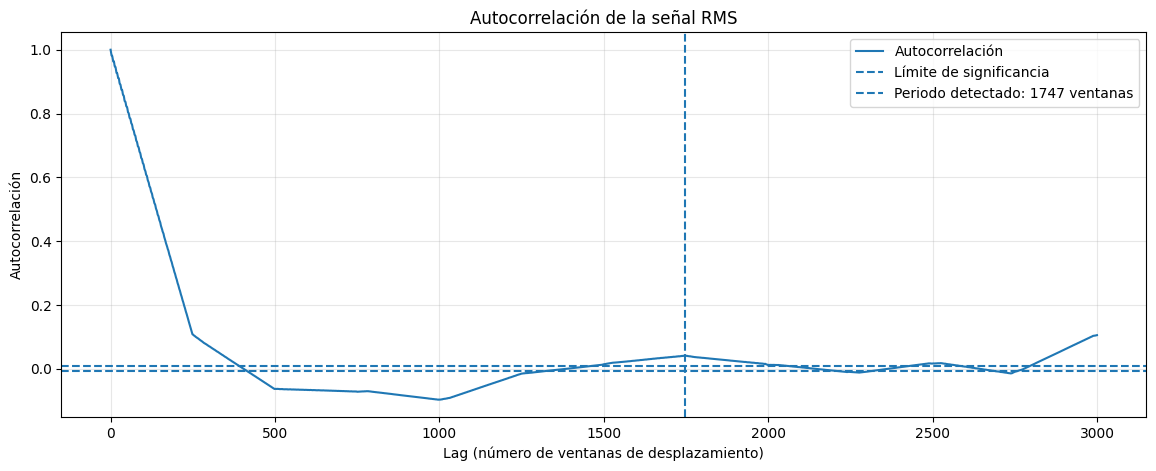

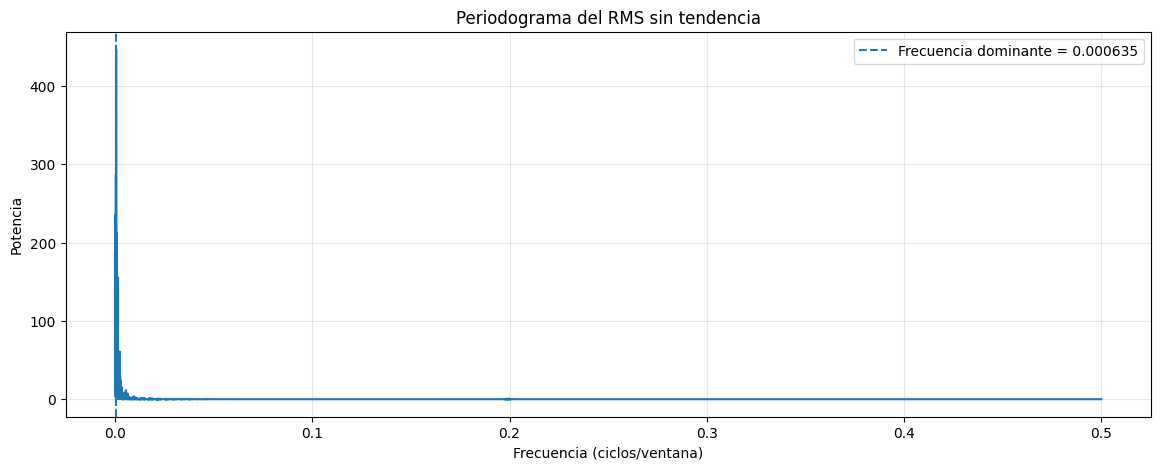


Periodo utilizado para STL: 1747 ventanas


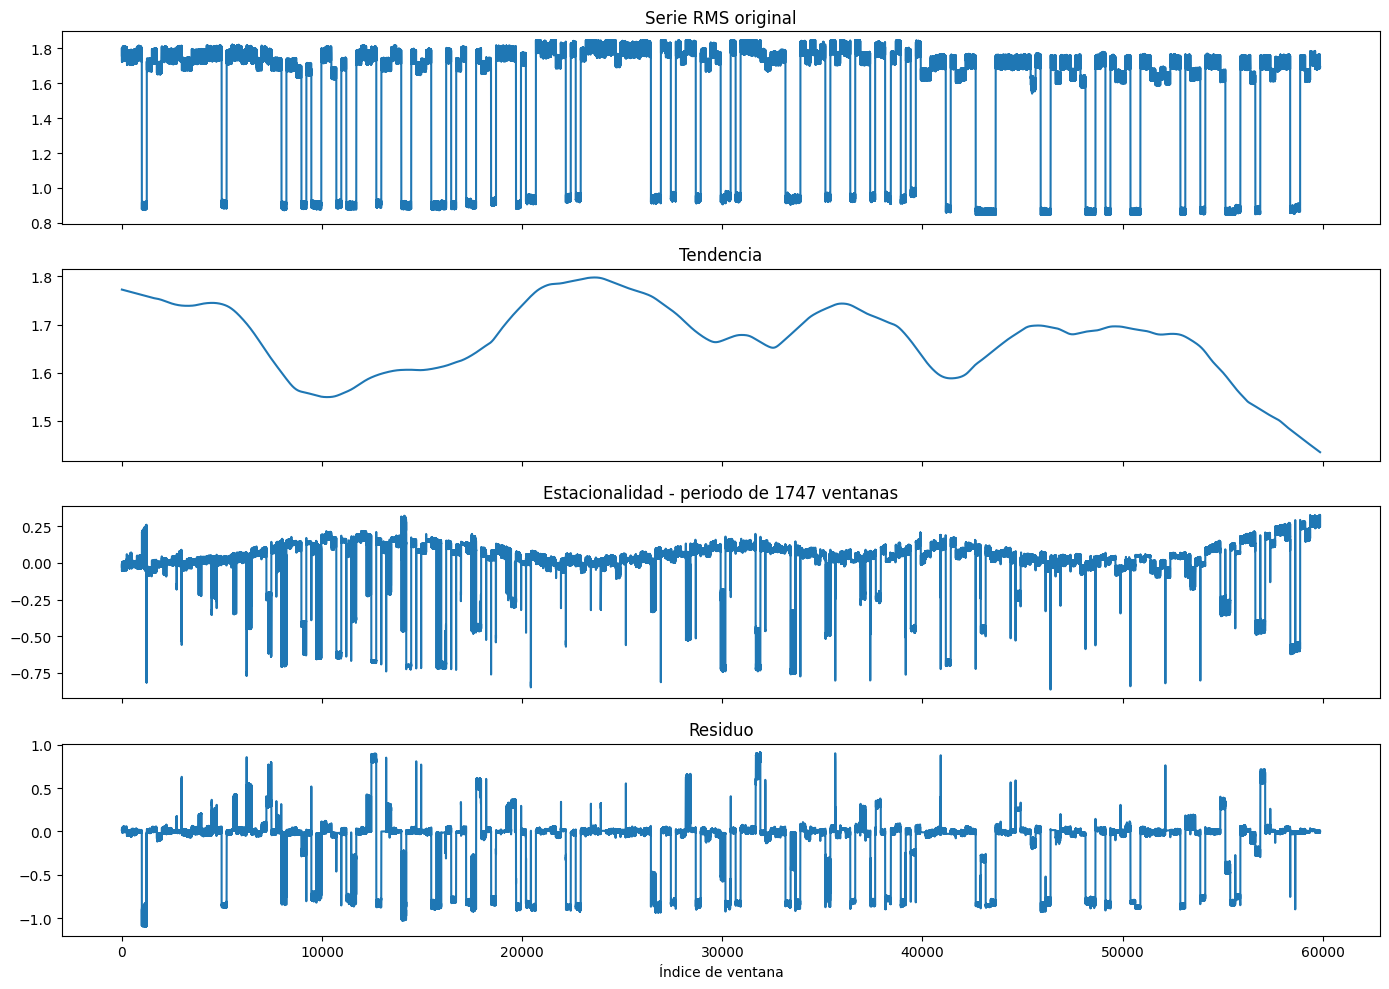

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import acf
from statsmodels.tsa.seasonal import STL
from scipy.signal import periodogram, find_peaks, detrend


# ============================================================
# 1. CARGAR DATASET
# ============================================================

ruta_csv = '/content/drive/MyDrive/Paderborn_QML/VERSION CON ATIPICOS TRATADOS/paderborn_features_tratadas.csv'

df = pd.read_csv(ruta_csv)

# El dataset contiene únicamente motores sanos
df_sano = df.copy().reset_index(drop=True)

# Característica que queremos estudiar
var_analisis = 'RMS'

serie = df_sano[var_analisis].astype(float).values

print("Cantidad de ventanas:", len(serie))
print("Característica analizada:", var_analisis)


# ============================================================
# 2. TENDENCIA
# ============================================================

# Para visualizar la tendencia usamos una media móvil.
ventana_tendencia = max(101, len(serie) // 100)

tendencia = (
    pd.Series(serie)
    .rolling(window=ventana_tendencia, center=True)
    .mean()
)


# ============================================================
# 3. AUTOCORRELACIÓN
# ============================================================

# Quitamos la tendencia antes de calcular la ACF.
# Esto evita que una tendencia lenta produzca correlaciones
# artificialmente altas.
serie_detrended = detrend(serie)

max_lag = min(3000, len(serie) // 4)

autocorr = acf(
    serie_detrended,
    nlags=max_lag,
    fft=True
)

# Intervalo aproximado de significancia
limite = 1.96 / np.sqrt(len(serie))


# Buscamos picos de autocorrelación.
# Ignoramos los primeros lags porque normalmente representan
# la similitud entre ventanas inmediatamente consecutivas.
picos, propiedades = find_peaks(
    autocorr[5:],
    height=limite,
    prominence=0.01,
    distance=10
)

picos = picos + 5


if len(picos) > 0:

    # Escogemos el pico con mayor autocorrelación
    mejor_pico = picos[np.argmax(autocorr[picos])]
    periodo_acf = mejor_pico

else:

    periodo_acf = None


# ============================================================
# 4. PERIODOGRAMA
# ============================================================

frecuencias, potencia = periodogram(
    serie_detrended
)

# Ignoramos frecuencia 0
frecuencias_utiles = frecuencias[1:]
potencia_util = potencia[1:]

idx = np.argmax(potencia_util)

frecuencia_dominante = frecuencias_utiles[idx]

if frecuencia_dominante > 0:
    periodo_periodograma = 1 / frecuencia_dominante
else:
    periodo_periodograma = None


# ============================================================
# 5. MOSTRAR RESULTADOS
# ============================================================

print("\n==============================================")
print("ANÁLISIS DE LA CARACTERÍSTICA:", var_analisis)
print("==============================================")

if periodo_acf is not None:
    print(f"Periodo detectado mediante ACF: {periodo_acf:.0f} ventanas")
else:
    print("ACF: no se encontró un periodo significativo")

print(
    f"Periodo dominante mediante periodograma: "
    f"{periodo_periodograma:.2f} ventanas"
)

print(f"Frecuencia dominante normalizada: {frecuencia_dominante:.6f} ciclos/ventana")


# ============================================================
# 6. GRÁFICA DE LA SERIE Y TENDENCIA
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    serie,
    label='RMS original'
)

plt.plot(
    tendencia,
    label='Tendencia'
)

plt.title(f'RMS del motor sano y tendencia')
plt.xlabel('Índice de ventana')
plt.ylabel('RMS')
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 7. GRÁFICA DE AUTOCORRELACIÓN
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    range(len(autocorr)),
    autocorr,
    label='Autocorrelación'
)

plt.axhline(
    limite,
    linestyle='--',
    label='Límite de significancia'
)

plt.axhline(
    -limite,
    linestyle='--'
)

if periodo_acf is not None:

    plt.axvline(
        periodo_acf,
        linestyle='--',
        label=f'Periodo detectado: {periodo_acf} ventanas'
    )

plt.title('Autocorrelación de la señal RMS')
plt.xlabel('Lag (número de ventanas de desplazamiento)')
plt.ylabel('Autocorrelación')
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 8. GRÁFICA DEL PERIODOGRAMA
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    frecuencias_utiles,
    potencia_util
)

plt.axvline(
    frecuencia_dominante,
    linestyle='--',
    label=f'Frecuencia dominante = {frecuencia_dominante:.6f}'
)

plt.title('Periodograma del RMS sin tendencia')
plt.xlabel('Frecuencia (ciclos/ventana)')
plt.ylabel('Potencia')

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 9. STL
# ============================================================

# Solo hacemos STL si encontramos una periodicidad razonable.
if periodo_acf is not None and periodo_acf >= 7:

    periodo_stl = periodo_acf

    # STL funciona mejor con períodos impares
    if periodo_stl % 2 == 0:
        periodo_stl += 1

    print(f"\nPeriodo utilizado para STL: {periodo_stl} ventanas")

    stl = STL(
        serie,
        period=periodo_stl,
        robust=True
    ).fit()

    tendencia_stl = stl.trend
    estacionalidad = stl.seasonal
    residuo = stl.resid


    # ========================================================
    # 10. GRAFICA STL
    # ========================================================

    fig, axes = plt.subplots(
        4,
        1,
        figsize=(14, 10),
        sharex=True
    )

    axes[0].plot(serie)
    axes[0].set_title('Serie RMS original')

    axes[1].plot(tendencia_stl)
    axes[1].set_title('Tendencia')

    axes[2].plot(estacionalidad)
    axes[2].set_title(
        f'Estacionalidad - periodo de {periodo_stl} ventanas'
    )

    axes[3].plot(residuo)
    axes[3].set_title('Residuo')

    axes[3].set_xlabel('Índice de ventana')

    plt.tight_layout()
    plt.show()

else:

    print(
        "\nNo se encontró una periodicidad suficientemente clara "
        "para justificar una descomposición STL."
    )